# Optimización PSO-XGBoost

Ejecuta el PSO, grafica la convergencia y muestra los hiperparámetros óptimos.

**Nota:** el PSO con 30 partículas y 50 iteraciones tarda varios minutos. Para una
exploración rápida puedes bajar `n_particles` y `n_iterations`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # raiz del proyecto para importar src
import logging
logging.basicConfig(level=logging.INFO)

In [2]:
import pandas as pd, matplotlib.pyplot as plt
from src import data_loader as dl, preprocessing as pp, config
from src.pso_optimizer import PSOXGBoostOptimizer
df = dl.load_ckd_dataset()
X_train, X_test, y_train, y_test = dl.split_data(df)
prep = pp.CKDPreprocessor()
X_train_p = prep.fit_transform(X_train); X_test_p = prep.transform(X_test)
X_res, y_res = pp.apply_smote(X_train_p, y_train)

2026-07-05 12:56:18,950 - src.data_loader - INFO - Dataset crudo cargado: 400 filas x 25 columnas


2026-07-05 12:56:18,954 - src.data_loader - INFO - Particion estratificada: train=320, test=80 (positivos train=0.62, test=0.62)


2026-07-05 12:56:18,971 - src.preprocessing - INFO - CKDPreprocessor ajustado: 28 features de salida


2026-07-05 12:56:19,051 - src.preprocessing - INFO - SMOTE aplicado: 320 -> 400 filas (positivos 0.62 -> 0.50)


## Corre el PSO

In [3]:
opt = PSOXGBoostOptimizer(X_res, y_res, random_state=config.RANDOM_SEED)
best_pos, history = opt.optimize()
opt.get_best_params()

2026-07-05 12:56:19,060 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.9}


pyswarms.single.global_best:   0%|          |0/50

pyswarms.single.global_best:   0%|          |0/50, best_cost=-0.999

pyswarms.single.global_best:   2%|▏         |1/50, best_cost=-0.999

pyswarms.single.global_best:   2%|▏         |1/50, best_cost=-0.999

...


2026-07-05 13:00:56,330 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.999375, best pos: [1.51878627e-01 2.59936639e+02 7.41317126e+00 1.43546754e+00
 7.94432589e-01 9.31142819e-01]


2026-07-05 13:00:56,334 - src.pso_optimizer - INFO - Convergencia guardada en /home/mickaell/Desktop/Proyectos de MICKAELL/ckd-early-prediction-pso-xgboost/results/pso_convergence.csv


2026-07-05 13:00:56,335 - src.pso_optimizer - INFO - PSO finalizado. Mejor AUC=0.9994


2026-07-05 13:00:56,335 - src.pso_optimizer - INFO - Mejores hiperparametros: {'learning_rate': 0.1518786265270035, 'n_estimators': 260, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.7944325891863092, 'colsample_bytree': 0.9311428191877087}


{'learning_rate': 0.1518786265270035,
 'n_estimators': 260,
 'max_depth': 7,
 'min_child_weight': 1,
 'subsample': 0.7944325891863092,
 'colsample_bytree': 0.9311428191877087}

## Convergencia

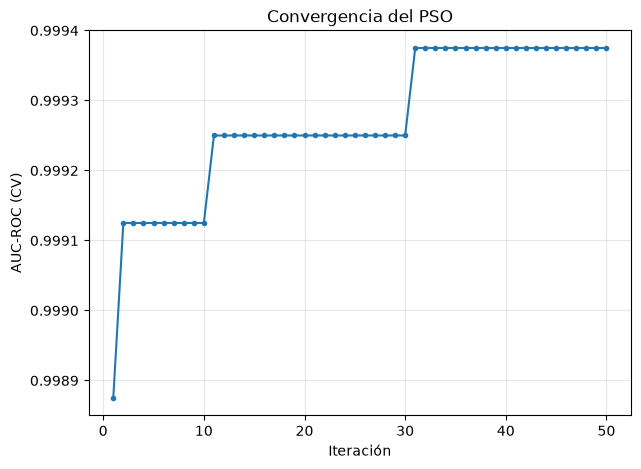

In [4]:
plt.figure(figsize=(7,5))
plt.plot(history['iteration'], history['best_auc'], marker='o', ms=3)
plt.xlabel('Iteración'); plt.ylabel('AUC-ROC (CV)'); plt.title('Convergencia del PSO')
plt.grid(alpha=0.3); plt.show()

## Modelo final y evaluación

In [5]:
from src.models import train_and_evaluate
model = opt.get_best_model(random_state=config.RANDOM_SEED)
model, metrics = train_and_evaluate(model, X_res, y_res, X_test_p, y_test)
{k: round(v,3) for k,v in metrics.items()}

{'accuracy': 0.975,
 'precision': 1.0,
 'recall': 0.96,
 'specificity': 1.0,
 'f1': 0.98,
 'auc_roc': 0.999,
 'mcc': 0.949}